# 5_evaluation_main — Evaluation

Evaluates the effect of each GEO method on citation visibility in the LLM-generated response.
All methods are compared against the baseline (`doc` = original document without any edit).

**Input:** `data/retail/4_generation_results_v1.parquet`, `data/retail/3_retrieval_geo_results_v2.csv`

## Structure
1. **Setup** — imports and paths
2. **Load Data** — load parquet + join retrieval ranks
3. **Descriptive Analysis** — dataset overview
4. **Helper Functions** — Delta Rank, PAWC, statistical functions
5. **H3a: Citation Rate** — Cochran's Q + McNemar confirmatory + post hoc
6. **H3b: Delta Rank** — Wilcoxon + Pratt confirmatory + post hoc
7. **H3c: PAWC** — Wilcoxon + Pratt confirmatory + post hoc
8. **H4: Retrieval → Citation** — Logistic Regression + model fit statistics
9. **Combined Results Table** — all three metrics side by side
10. **Combination Analysis** — heatmap and bar chart

## 1. Setup

In [32]:
import os
import math
import re
import itertools
from collections import Counter

import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import wilcoxon, norm, chi2
from sklearn.metrics import roc_auc_score
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.contingency_tables import mcnemar

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))
data_dir     = os.path.join(project_root, "data", "retail")

print("Setup complete.")

Setup complete.


## 2. Load Data

Loads the generation results and joins the target retrieval rank from the retrieval CSV.
Helper columns added:
- `target_cited` — 1 if target was cited in LLM response, 0 otherwise
- `target_retrieval_rank` — position of target doc in Vertex AI Search results (1-10)

In [33]:
results_path = os.path.join(data_dir, "4_generation_results_v1.parquet")
df = pd.read_parquet(results_path)

df["citation_order"] = df["citation_order"].apply(
    lambda x: x.tolist() if isinstance(x, np.ndarray) else x
)

retrieval_csv_path = os.path.join(data_dir, "3_retrieval_geo_results_v2.csv")
df_retrieval = pd.read_csv(retrieval_csv_path)
target_retrieval = df_retrieval[df_retrieval["is_target"] == 1][["query_id", "rank"]].copy()
target_retrieval = target_retrieval.rename(columns={"rank": "target_retrieval_rank"})
df = df.merge(target_retrieval, on="query_id", how="left")

df["target_cited"] = df.apply(
    lambda row: 1 if row["target_new_position"] in row["citation_order"] else 0, axis=1
)

df_baseline = df[df["method"] == "doc"].reset_index(drop=True)
all_methods = sorted([m for m in df["method"].unique() if m != "doc"])

print(f"Total rows:              {len(df)}")
print(f"Baseline rows:           {len(df_baseline)}")
print(f"Methods to evaluate:     {len(all_methods)}")
print(f"Unique original queries: {df['original_query_id'].nunique()}")
print(f"Rows with retrieval rank: {df['target_retrieval_rank'].notna().sum()}")

Total rows:              10940
Baseline rows:           499
Methods to evaluate:     21
Unique original queries: 500
Rows with retrieval rank: 10940


## 3. Descriptive Analysis

In [34]:
print("=" * 60)
print("DESCRIPTIVE ANALYSIS")
print("=" * 60)

print("\n--- 1. Dataset Overview ---")
print(f"Total runs:              {len(df)}")
print(f"Unique original queries: {df['original_query_id'].nunique()}")
print(f"Unique methods:          {df['method'].nunique()}")
print(f"Runs per query (mean):   {len(df) / df['original_query_id'].nunique():.1f}")

print("\n--- 2. Documents per Run ---")
print(f"Mean:   {df['num_docs'].mean():.2f} | Median: {df['num_docs'].median():.0f} | Min: {df['num_docs'].min()} | Max: {df['num_docs'].max()}")
for k, v in df['num_docs'].value_counts().sort_index().items():
    print(f"  {int(k):>2} docs: {v:>5} runs ({v/len(df):.1%})  {'█' * int(v/len(df)*100)}")

print("\n--- 3. Citations per LLM Response ---")
df["num_citations"] = df["citation_order"].apply(len)
print(f"Mean:   {df['num_citations'].mean():.2f} | Median: {df['num_citations'].median():.0f} | Min: {df['num_citations'].min()} | Max: {df['num_citations'].max()}")
for k, v in df["num_citations"].value_counts().sort_index().items():
    print(f"  {int(k):>2} citations: {v:>5} runs ({v/len(df):.1%})  {'█' * int(v/len(df)*100)}")

print("\n--- 4. Target Retrieval Rank Distribution ---")
print(f"Mean: {df['target_retrieval_rank'].mean():.2f} | Median: {df['target_retrieval_rank'].median():.0f}")
for k, v in df["target_retrieval_rank"].value_counts().sort_index().items():
    print(f"  Rank {int(k):>2}: {v:>5} runs ({v/len(df):.1%})  {'█' * int(v/len(df)*50)}")

print("\n--- 5. Overall Citation Statistics ---")
print(f"Overall citation rate: {df['target_cited'].mean():.1%}")
print(f"Cited:     {df['target_cited'].sum():.0f} / {len(df)}")
print(f"Not cited: {(1 - df['target_cited']).sum():.0f} / {len(df)}")

print("\n--- 6. LLM Response Length (words) ---")
df["response_length"] = df["llm_response"].apply(lambda x: len(x.split()))
print(f"Mean: {df['response_length'].mean():.1f} | Median: {df['response_length'].median():.0f} | Min: {df['response_length'].min()} | Max: {df['response_length'].max()}")

DESCRIPTIVE ANALYSIS

--- 1. Dataset Overview ---
Total runs:              10940
Unique original queries: 500
Unique methods:          22
Runs per query (mean):   21.9

--- 2. Documents per Run ---
Mean:   9.98 | Median: 10 | Min: 4 | Max: 10
   4 docs:     4 runs (0.0%)  
   7 docs:    22 runs (0.2%)  
   8 docs:     4 runs (0.0%)  
   9 docs:   165 runs (1.5%)  █
  10 docs: 10745 runs (98.2%)  ██████████████████████████████████████████████████████████████████████████████████████████████████

--- 3. Citations per LLM Response ---
Mean:   6.38 | Median: 6 | Min: 0 | Max: 10
   0 citations:   109 runs (1.0%)  
   1 citations:    85 runs (0.8%)  
   2 citations:   100 runs (0.9%)  
   3 citations:   307 runs (2.8%)  ██
   4 citations:   649 runs (5.9%)  █████
   5 citations:  2187 runs (20.0%)  ███████████████████
   6 citations:  2425 runs (22.2%)  ██████████████████████
   7 citations:  2094 runs (19.1%)  ███████████████████
   8 citations:  1493 runs (13.6%)  █████████████
   9 citati

## 4. Helper Functions

### Delta Rank (Puerto 2025)
Difference: `baseline_position - method_position`. Positive = method improved citation position.
Uses `max_citations=6` — set to median citation count in our data (Median=6, Mean=6.38),
vs. Puerto (2025) who uses max_citations=5 based on his data distribution.
Applies Wilcoxon with **Pratt modification** — retains zero differences in ranking,
since zeros (no change) are informative observations and should influence the rank structure.

### PAWC (Aggarwal 2024)
Position-Adjusted Word Count: word count × exponential position decay, normalized per run.
Applies Wilcoxon with **Pratt modification** for consistency with Delta Rank.

### Statistical approach
- **Cochran's Q** — global gatekeeper for H3a
- **McNemar** — paired binary test for H3a (no Pratt equivalent)
- **Wilcoxon (Pratt)** — paired non-parametric test for H3b, H3c
- **Bonferroni-Holm** — Step 2 correction across 21 comparisons
- **Confirmatory (one-sided)** — based on prior literature expecting positive effects
- **Post hoc exploratory (two-sided)** — motivated by unexpected negative effect of Statistics
- **Effect sizes** — Odds Ratio for H3a, r = Z/√N for H3b and H3c

In [35]:
# --- Delta Rank ---

def calculate_significant_improvements(df_baseline, df_method, max_citations=6):
    """
    Computes Delta Rank: baseline_position - method_position.
    max_citations=6 based on Median=6, Mean=6.38 in our data.
    Wilcoxon with Pratt modification. Adapted from Puerto (2025).
    """
    all_differences = []
    n = min(len(df_baseline), len(df_method))
    df_baseline = df_baseline.reset_index(drop=True)
    df_method   = df_method.reset_index(drop=True)

    for i in range(n):
        baseline_order = df_baseline.loc[i, "citation_order"]
        method_order   = df_method.loc[i, "citation_order"]
        if isinstance(baseline_order, np.ndarray):
            baseline_order = baseline_order.tolist()[:max_citations]
        if isinstance(method_order, np.ndarray):
            method_order = method_order.tolist()[:max_citations]

        boosted_item  = df_method.loc[i, "target_new_position"]
        boosted_items = [boosted_item] if not isinstance(boosted_item, list) else boosted_item

        for item in boosted_items:
            if (item in baseline_order) and (item in method_order):
                diff = baseline_order.index(item) - method_order.index(item)
            elif (item in baseline_order) and (item not in method_order):
                diff = baseline_order.index(item) - len(method_order)
            elif (item not in baseline_order) and (item in method_order):
                diff = len(baseline_order) - method_order.index(item)
            else:
                diff = 0
            all_differences.append(diff)

    if len(all_differences) == 0:
        return {"statistic": None, "pvalue_greater": None, "pvalue_less": None,
                "pvalue_twosided": None, "Delta Rank": (None, None), "diffs": [], "r_effect": None}

    stat_g, pval_g = wilcoxon(all_differences, alternative="greater",   zero_method="pratt")
    stat_l, pval_l = wilcoxon(all_differences, alternative="less",      zero_method="pratt")
    stat_t, pval_t = wilcoxon(all_differences, alternative="two-sided", zero_method="pratt")

    mean_diff = np.mean(all_differences)
    std_diff  = np.std(all_differences)
    N         = len(all_differences)
    z_stat    = norm.ppf(1 - pval_g) if 0 < pval_g < 1 else 0.0
    r_effect  = abs(z_stat) / np.sqrt(N)

    return {
        "statistic":       stat_g,
        "pvalue_greater":  pval_g,
        "pvalue_less":     pval_l,
        "pvalue_twosided": pval_t,
        "Delta Rank":      (mean_diff, std_diff),
        "diffs":           all_differences,
        "r_effect":        r_effect,
    }


# --- PAWC ---

def get_num_words(tokens):
    """Count words longer than 2 characters — exactly like Aggarwal (2024)."""
    return len([x for x in tokens if len(x) > 2])


def extract_citations(text):
    """Splits LLM response into sentences and extracts citation indices. Adapted from Aggarwal."""
    citation_pattern = r'\[[^\w\s]*\d+[^\w\s]*\]'
    def get_citations(sentence):
        return [int(re.findall(r'\d+', c)[0]) for c in re.findall(citation_pattern, sentence)]
    paras     = re.split(r'\n\n', text)
    sentences = [nltk.sent_tokenize(p) for p in paras if p.strip()]
    return [[(nltk.word_tokenize(s), s, get_citations(s)) for s in para] for para in sentences]


def pawc(sentences_nested, target_citation_idx, normalize=True):
    """
    Position-Adjusted Word Count. Score = word_count x exp(-i/(N-1)) / num_citations_in_sentence.
    Normalized so all document scores sum to 1. Adapted from Aggarwal (2024).
    """
    sentences = list(itertools.chain(*sentences_nested))
    n = max([max(s[2]) for s in sentences if s[2]] + [1])
    scores = [0.0 for _ in range(n)]
    for i, sent in enumerate(sentences):
        for cit in sent[2]:
            score  = get_num_words(sent[0])
            score *= math.exp(-1 * i / (len(sentences) - 1)) if len(sentences) > 1 else 1
            score /= len(sent[2])
            try:
                scores[cit - 1] += score
            except:
                pass
    total = sum(scores)
    if normalize and total > 0:
        scores = [x / total for x in scores]
    try:
        return scores[target_citation_idx - 1]
    except:
        return 0.0


def compute_pawc_for_row(row):
    """Computes PAWC for one run. target_new_position is 0-based → +1 for 1-based."""
    try:
        sentences = extract_citations(row["llm_response"])
        return pawc(sentences, row["target_new_position"] + 1, normalize=True)
    except:
        return 0.0


# --- Hosmer-Lemeshow ---

def hosmer_lemeshow(y_true, y_pred, g=10):
    """Tests whether predicted probabilities match observed outcomes. p > 0.05 = good fit."""
    data = pd.DataFrame({"y": y_true, "p": y_pred})
    data["decile"] = pd.qcut(data["p"], g, duplicates="drop")
    grouped  = data.groupby("decile").agg(observed=("y", "sum"), total=("y", "count"), expected=("p", "sum"))
    hl_stat  = ((grouped["observed"] - grouped["expected"]) ** 2 /
                (grouped["expected"] * (1 - grouped["expected"] / grouped["total"]))).sum()
    p_val    = 1 - chi2.cdf(hl_stat, df=g - 2)
    return hl_stat, p_val


print("Helper functions defined.")

Helper functions defined.


## 5. H3a: Citation Rate — Do GEO Interventions Increase Citation Probability?

**H0:** No GEO intervention increases the probability of the target document being cited compared to the baseline.
**HA:** At least one GEO intervention significantly increases citation probability compared to the baseline.

**Step 0 — Cochran's Q:** Global gatekeeper — tests whether citation rates differ across all 22 methods.
Pairwise McNemar tests only follow if Q is significant.

**Confirmatory:** McNemar one-sided (greater) + Bonferroni-Holm.
Based on prior literature (Aggarwal 2024, Puerto 2025) reporting positive effects only.

**Post hoc exploratory:** McNemar two-sided + Bonferroni-Holm.
Motivated by unexpected negative effect of Statistics intervention.

**Effect size:** Odds Ratio = b/c — improvements over deteriorations from discordant pairs.

In [36]:
# --- Step 0: Cochran's Q Test ---

all_methods_incl_baseline = ["doc"] + all_methods
cited_matrix = pd.pivot_table(
    df, values="target_cited",
    index="original_query_id", columns="method", aggfunc="first"
)[all_methods_incl_baseline].dropna()

n_subjects = cited_matrix.shape[0]
k          = cited_matrix.shape[1]
row_sums   = cited_matrix.sum(axis=1)
col_sums   = cited_matrix.sum(axis=0)
total      = cited_matrix.values.sum()

Q_num  = (k - 1) * (k * np.sum(col_sums ** 2) - total ** 2)
Q_den  = k * total - np.sum(row_sums ** 2)
Q_stat = Q_num / Q_den if Q_den != 0 else 0
Q_pval = 1 - chi2.cdf(Q_stat, df=k - 1)

print("=" * 60)
print("Step 0 — Cochran's Q Test (Global Gatekeeper)")
print("=" * 60)
print(f"Subjects (queries): {n_subjects}  |  Methods: {k}")
print(f"Q statistic: {Q_stat:.4f}  |  df: {k-1}  |  p-value: {Q_pval:.4g}")
print()
if Q_pval < 0.05:
    print("→ Significant (p < 0.05): Citation rates differ across methods.")
    print("→ Proceeding with pairwise McNemar tests.")
else:
    print("→ Not significant (p >= 0.05): No global difference detected.")
    print("→ Pairwise McNemar results should be interpreted with caution.")

Step 0 — Cochran's Q Test (Global Gatekeeper)
Subjects (queries): 477  |  Methods: 22
Q statistic: 176.7287  |  df: 21  |  p-value: 0

→ Significant (p < 0.05): Citation rates differ across methods.
→ Proceeding with pairwise McNemar tests.


In [37]:
# --- Confirmatory: McNemar one-sided (greater) ---

df_base_cited = df[df["method"] == "doc"][["original_query_id", "target_cited"]].rename(
    columns={"target_cited": "cited_baseline"}
)
citation_rate = df.groupby("method")["target_cited"].mean().reset_index()
citation_rate.columns = ["method", "citation_rate"]
baseline_citation_rate = citation_rate[citation_rate["method"] == "doc"]["citation_rate"].values[0]

mcnemar_results = []
for method in all_methods:
    df_mc = df[df["method"] == method][["original_query_id", "target_cited"]].rename(
        columns={"target_cited": "cited_method"}
    )
    merged    = df_base_cited.merge(df_mc, on="original_query_id")
    both      = ((merged["cited_baseline"] == 1) & (merged["cited_method"] == 1)).sum()
    only_base = ((merged["cited_baseline"] == 1) & (merged["cited_method"] == 0)).sum()
    only_meth = ((merged["cited_baseline"] == 0) & (merged["cited_method"] == 1)).sum()
    neither   = ((merged["cited_baseline"] == 0) & (merged["cited_method"] == 0)).sum()

    table  = [[both, only_base], [only_meth, neither]]
    p_two  = mcnemar(table, exact=False, correction=True).pvalue
    p_greater = p_two / 2 if only_meth > only_base else 1 - p_two / 2
    odds_ratio = only_meth / only_base if only_base > 0 else np.nan

    method_rate = citation_rate[citation_rate["method"] == method]["citation_rate"].values[0]
    mcnemar_results.append({
        "method":            method,
        "citation_rate":     method_rate,
        "delta":             method_rate - baseline_citation_rate,
        "b":                 only_meth,
        "c":                 only_base,
        "pvalue_greater":    p_greater,
        "pvalue_twosided":   p_two,
        "odds_ratio":        odds_ratio,
    })

df_citation = pd.DataFrame(mcnemar_results).sort_values("delta", ascending=False)

# Step 1 — raw
print(f"Baseline citation rate (doc): {baseline_citation_rate:.1%}")
print()
print("Confirmatory — Step 1: McNemar One-Sided (greater), raw p-values")
print(f"{'Method':<30} {'Cit. Rate':>10} {'Delta':>8} {'p+ (raw)':>12} {'Sig':>5} {'OR':>8}")
print("-" * 80)
for _, row in df_citation.iterrows():
    sig    = "*" if row["pvalue_greater"] < 0.05 else ""
    or_str = f"{row['odds_ratio']:.3f}" if not np.isnan(row["odds_ratio"]) else "N/A"
    print(f"  {row['method']:<28} {row['citation_rate']:>9.1%} {row['delta']:>+7.1%} {row['pvalue_greater']:>12.4g} {sig:>5} {or_str:>8}")

# Step 2 — Bonferroni-Holm
_, pvals_g_holm, _, _ = multipletests(df_citation["pvalue_greater"].values, method="holm")
df_citation["pvalue_greater_holm"] = pvals_g_holm

print()
print("Confirmatory — Step 2: Bonferroni-Holm Correction")
print(f"{'Method':<30} {'Cit. Rate':>10} {'Delta':>8} {'p+ (Holm)':>12} {'Sig':>5} {'OR':>8}")
print("-" * 80)
for _, row in df_citation.iterrows():
    sig    = "*" if row["pvalue_greater_holm"] < 0.05 else ""
    or_str = f"{row['odds_ratio']:.3f}" if not np.isnan(row["odds_ratio"]) else "N/A"
    print(f"  {row['method']:<28} {row['citation_rate']:>9.1%} {row['delta']:>+7.1%} {row['pvalue_greater_holm']:>12.4g} {sig:>5} {or_str:>8}")

Baseline citation rate (doc): 62.3%

Confirmatory — Step 1: McNemar One-Sided (greater), raw p-values
Method                          Cit. Rate    Delta     p+ (raw)   Sig       OR
--------------------------------------------------------------------------------
  CS(doc)                          69.4%   +7.0%     0.001305     *    1.825
  Authoritative(doc)               68.0%   +5.7%     0.005585     *    1.692
  Fluency(doc)                     66.9%   +4.5%      0.03223     *    1.438
  TechnicalTerms(doc)              66.3%   +3.9%      0.03758     *    1.426
  QS(doc)                          65.6%   +3.3%       0.0762          1.315
  CQS(doc)                         65.4%   +3.1%       0.1034          1.304
  ContentImprovement(doc)          65.2%   +2.9%      0.09968          1.288
  CQ(doc)                          64.9%   +2.5%       0.1577          1.222
  UniqueWords(doc)                 64.1%   +1.7%       0.3001          1.113
  FCQ(doc)                         63.5%   +1

In [38]:
# --- Post Hoc Exploratory: McNemar two-sided ---
# H0: No intervention changes citation probability in either direction.
# HA: At least one intervention significantly changes citation probability.

_, pvals_t_holm, _, _ = multipletests(df_citation["pvalue_twosided"].values, method="holm")
df_citation["pvalue_twosided_holm"] = pvals_t_holm

print("Post Hoc Exploratory — Step 1: McNemar Two-Sided, raw p-values")
print(f"{'Method':<30} {'Cit. Rate':>10} {'Delta':>8} {'p (raw)':>12} {'Sig':>5} {'OR':>8}")
print("-" * 80)
for _, row in df_citation.iterrows():
    sig    = "*" if row["pvalue_twosided"] < 0.05 else ""
    or_str = f"{row['odds_ratio']:.3f}" if not np.isnan(row["odds_ratio"]) else "N/A"
    print(f"  {row['method']:<28} {row['citation_rate']:>9.1%} {row['delta']:>+7.1%} {row['pvalue_twosided']:>12.4g} {sig:>5} {or_str:>8}")

print()
print("Post Hoc Exploratory — Step 2: Bonferroni-Holm Correction")
print(f"{'Method':<30} {'Cit. Rate':>10} {'Delta':>8} {'p (Holm)':>12} {'Sig':>5} {'OR':>8}")
print("-" * 80)
for _, row in df_citation.iterrows():
    sig    = "*" if row["pvalue_twosided_holm"] < 0.05 else ""
    or_str = f"{row['odds_ratio']:.3f}" if not np.isnan(row["odds_ratio"]) else "N/A"
    print(f"  {row['method']:<28} {row['citation_rate']:>9.1%} {row['delta']:>+7.1%} {row['pvalue_twosided_holm']:>12.4g} {sig:>5} {or_str:>8}")

print()
print("OR = Odds Ratio (b/c). OR > 1 = more improvements than deteriorations.")

Post Hoc Exploratory — Step 1: McNemar Two-Sided, raw p-values
Method                          Cit. Rate    Delta      p (raw)   Sig       OR
--------------------------------------------------------------------------------
  CS(doc)                          69.4%   +7.0%      0.00261     *    1.825
  Authoritative(doc)               68.0%   +5.7%      0.01117     *    1.692
  Fluency(doc)                     66.9%   +4.5%      0.06446          1.438
  TechnicalTerms(doc)              66.3%   +3.9%      0.07516          1.426
  QS(doc)                          65.6%   +3.3%       0.1524          1.315
  CQS(doc)                         65.4%   +3.1%       0.2067          1.304
  ContentImprovement(doc)          65.2%   +2.9%       0.1994          1.288
  CQ(doc)                          64.9%   +2.5%       0.3153          1.222
  UniqueWords(doc)                 64.1%   +1.7%       0.6001          1.113
  FCQ(doc)                         63.5%   +1.1%       0.7344          1.075
  Citat

## 6. H3b: Delta Citation Rank — Do GEO Interventions Improve Citation Position?

**H0:** No GEO intervention causes the target document to be cited earlier compared to the baseline.
**HA:** At least one GEO intervention significantly causes the target to be cited earlier.

**max_citations=6** — based on Median=6, Mean=6.38 in our data (Puerto 2025 uses 5).
**Wilcoxon + Pratt modification** — zero differences are retained in the ranking step.
**Effect size:** r = Z / √N.

**Confirmatory:** one-sided (greater) + Bonferroni-Holm.
**Post hoc exploratory:** two-sided + Bonferroni-Holm.

In [39]:
# --- Confirmatory: Wilcoxon one-sided (greater) + Pratt ---

results_delta = []
for method in all_methods:
    df_m = df[df["method"] == method].reset_index(drop=True)
    common = set(df_baseline["original_query_id"]) & set(df_m["original_query_id"])
    df_b_a = df_baseline[df_baseline["original_query_id"].isin(common)].sort_values("original_query_id").reset_index(drop=True)
    df_m_a = df_m[df_m["original_query_id"].isin(common)].sort_values("original_query_id").reset_index(drop=True)
    res    = calculate_significant_improvements(df_b_a, df_m_a)
    results_delta.append({
        "method":          method,
        "n_queries":       len(common),
        "delta_rank":      res["Delta Rank"][0],
        "delta_rank_std":  res["Delta Rank"][1],
        "pvalue_greater":  res["pvalue_greater"],
        "pvalue_less":     res["pvalue_less"],
        "pvalue_twosided": res["pvalue_twosided"],
        "r_effect":        res["r_effect"],
    })

df_results = pd.DataFrame(results_delta).sort_values("delta_rank", ascending=False)

# Step 1
print("Confirmatory — Step 1: Wilcoxon One-Sided (greater) + Pratt, raw p-values")
print(f"{'Method':<30} {'Delta Rank':>12} {'Std':>8} {'p+ (raw)':>12} {'Sig':>4} {'r':>8}")
print("-" * 80)
for _, row in df_results.iterrows():
    sig = "*" if row["pvalue_greater"] < 0.05 else ""
    print(f"  {row['method']:<28} {row['delta_rank']:>12.4f} {row['delta_rank_std']:>8.4f} {row['pvalue_greater']:>12.4g} {sig:>4} {row['r_effect']:>8.4f}")

# Step 2
_, pg_holm, _, _ = multipletests(df_results["pvalue_greater"].values, method="holm")
df_results["pvalue_greater_holm"] = pg_holm

print()
print("Confirmatory — Step 2: Bonferroni-Holm Correction")
print(f"{'Method':<30} {'Delta Rank':>12} {'Std':>8} {'p+ (Holm)':>12} {'Sig':>4} {'r':>8}")
print("-" * 80)
for _, row in df_results.iterrows():
    sig = "*" if row["pvalue_greater_holm"] < 0.05 else ""
    print(f"  {row['method']:<28} {row['delta_rank']:>12.4f} {row['delta_rank_std']:>8.4f} {row['pvalue_greater_holm']:>12.4g} {sig:>4} {row['r_effect']:>8.4f}")

Confirmatory — Step 1: Wilcoxon One-Sided (greater) + Pratt, raw p-values
Method                           Delta Rank      Std     p+ (raw)  Sig        r
--------------------------------------------------------------------------------
  ContentImprovement(doc)            0.2903   2.0558     0.002966    *   0.1235
  Authoritative(doc)                 0.2440   2.1306      0.01825    *   0.0939
  CQ(doc)                            0.2213   2.0387      0.08215        0.0624
  QS(doc)                            0.2198   2.0601      0.00325    *   0.1222
  LLMstxt(doc)                       0.2193   2.2388      0.05377        0.0722
  UniqueWords(doc)                   0.2133   2.0912      0.03532    *   0.0811
  FQ(doc)                            0.2036   2.0213      0.03335    *   0.0823
  FCQS(doc)                          0.1947   2.1064      0.06694        0.0675
  TechnicalTerms(doc)                0.1891   2.0761       0.1003        0.0574
  CQS(doc)                           0.1714  

In [40]:
# --- Post Hoc Exploratory: Wilcoxon two-sided + Pratt ---

_, pt_holm, _, _ = multipletests(df_results["pvalue_twosided"].values, method="holm")
df_results["pvalue_twosided_holm"] = pt_holm

print("Post Hoc Exploratory — Step 1: Wilcoxon Two-Sided + Pratt, raw p-values")
print(f"{'Method':<30} {'Delta Rank':>12} {'Std':>8} {'p (raw)':>12} {'Sig':>4} {'r':>8}")
print("-" * 80)
for _, row in df_results.iterrows():
    sig = "*" if row["pvalue_twosided"] < 0.05 else ""
    print(f"  {row['method']:<28} {row['delta_rank']:>12.4f} {row['delta_rank_std']:>8.4f} {row['pvalue_twosided']:>12.4g} {sig:>4} {row['r_effect']:>8.4f}")

print()
print("Post Hoc Exploratory — Step 2: Bonferroni-Holm Correction")
print(f"{'Method':<30} {'Delta Rank':>12} {'Std':>8} {'p (Holm)':>12} {'Sig':>4} {'r':>8}")
print("-" * 80)
for _, row in df_results.iterrows():
    sig = "*" if row["pvalue_twosided_holm"] < 0.05 else ""
    print(f"  {row['method']:<28} {row['delta_rank']:>12.4f} {row['delta_rank_std']:>8.4f} {row['pvalue_twosided_holm']:>12.4g} {sig:>4} {row['r_effect']:>8.4f}")

print()
print("Positive Delta Rank = cited earlier. Negative = cited later.")
print("Effect size r: 0.1 = small, 0.3 = medium, 0.5 = large.")

Post Hoc Exploratory — Step 1: Wilcoxon Two-Sided + Pratt, raw p-values
Method                           Delta Rank      Std      p (raw)  Sig        r
--------------------------------------------------------------------------------
  ContentImprovement(doc)            0.2903   2.0558     0.005932    *   0.1235
  Authoritative(doc)                 0.2440   2.1306       0.0365    *   0.0939
  CQ(doc)                            0.2213   2.0387       0.1643        0.0624
  QS(doc)                            0.2198   2.0601     0.006501    *   0.1222
  LLMstxt(doc)                       0.2193   2.2388       0.1075        0.0722
  UniqueWords(doc)                   0.2133   2.0912      0.07063        0.0811
  FQ(doc)                            0.2036   2.0213       0.0667        0.0823
  FCQS(doc)                          0.1947   2.1064       0.1339        0.0675
  TechnicalTerms(doc)                0.1891   2.0761       0.2006        0.0574
  CQS(doc)                           0.1714   2

## 7. H3c: PAWC — Do GEO Interventions Increase Citation Word Volume?

**H0:** No GEO intervention increases the position-weighted word volume attributed to the target document.
**HA:** At least one GEO intervention significantly increases position-weighted word volume.

**Formula:** `score += word_count × exp(-i/(N-1)) / num_citations_in_sentence`, normalized per run.
**Wilcoxon + Pratt modification** for consistency with Delta Rank.
**Effect size:** r = Z / √N.

**Confirmatory:** one-sided (greater) + Bonferroni-Holm.
**Post hoc exploratory:** two-sided + Bonferroni-Holm.

In [41]:
# Compute PAWC
print("Computing PAWC for all runs...")
df["pawc"] = df.apply(compute_pawc_for_row, axis=1)
print(f"Done — PAWC computed for {len(df)} rows")

baseline_pawc = df[df["method"] == "doc"]["pawc"].mean()
pawc_summary  = df.groupby("method")["pawc"].mean().reset_index()
pawc_summary.columns = ["method", "mean_pawc"]
pawc_summary["delta_pawc"] = pawc_summary["mean_pawc"] - baseline_pawc
pawc_summary = pawc_summary.sort_values("delta_pawc", ascending=False)

print(f"\nBaseline PAWC (doc): {baseline_pawc:.6f}")
print()
print(f"{'Method':<30} {'Mean PAWC':>12} {'Delta PAWC':>12}")
print("-" * 58)
for _, row in pawc_summary.iterrows():
    print(f"  {row['method']:<28} {row['mean_pawc']:>12.6f} {row['delta_pawc']:>+12.6f}")

Computing PAWC for all runs...
Done — PAWC computed for 10940 rows

Baseline PAWC (doc): 0.095637

Method                            Mean PAWC   Delta PAWC
----------------------------------------------------------
  CS(doc)                          0.111528    +0.015891
  CQS(doc)                         0.110659    +0.015022
  Authoritative(doc)               0.108672    +0.013034
  Citations(doc)                   0.107162    +0.011525
  QS(doc)                          0.106294    +0.010657
  FCQS(doc)                        0.104854    +0.009217
  TechnicalTerms(doc)              0.104712    +0.009075
  SimpleLanguage(doc)              0.103492    +0.007855
  Quotes(doc)                      0.103384    +0.007746
  Fluency(doc)                     0.103180    +0.007543
  ContentImprovement(doc)          0.102414    +0.006777
  CQ(doc)                          0.102218    +0.006580
  UniqueWords(doc)                 0.098998    +0.003361
  FCS(doc)                         0.098504 

In [42]:
# --- Confirmatory: Wilcoxon one-sided (greater) + Pratt ---

df_base_pawc = df[df["method"] == "doc"][["original_query_id", "pawc"]].rename(columns={"pawc": "pawc_baseline"})

pawc_results = []
for method in all_methods:
    df_mp  = df[df["method"] == method][["original_query_id", "pawc"]].rename(columns={"pawc": "pawc_method"})
    merged = df_base_pawc.merge(df_mp, on="original_query_id")
    diffs  = (merged["pawc_method"] - merged["pawc_baseline"]).tolist()
    if len(diffs) < 10:
        continue
    stat_g, pval_g = wilcoxon(diffs, alternative="greater",   zero_method="pratt")
    stat_l, pval_l = wilcoxon(diffs, alternative="less",      zero_method="pratt")
    stat_t, pval_t = wilcoxon(diffs, alternative="two-sided", zero_method="pratt")
    N        = len(diffs)
    z_stat   = norm.ppf(1 - pval_g) if 0 < pval_g < 1 else 0.0
    r_effect = abs(z_stat) / np.sqrt(N)
    pawc_results.append({
        "method":          method,
        "mean_delta_pawc": np.mean(diffs),
        "pvalue_greater":  pval_g,
        "pvalue_less":     pval_l,
        "pvalue_twosided": pval_t,
        "r_effect":        r_effect,
    })

df_pawc = pd.DataFrame(pawc_results).sort_values("mean_delta_pawc", ascending=False)

# Step 1
print("Confirmatory — Step 1: Wilcoxon One-Sided (greater) + Pratt, raw p-values")
print(f"{'Method':<30} {'Δ PAWC':>12} {'p+ (raw)':>12} {'Sig':>4} {'r':>8}")
print("-" * 72)
for _, row in df_pawc.iterrows():
    sig = "*" if row["pvalue_greater"] < 0.05 else ""
    print(f"  {row['method']:<28} {row['mean_delta_pawc']:>12.6f} {row['pvalue_greater']:>12.4g} {sig:>4} {row['r_effect']:>8.4f}")

# Step 2
_, pg_holm, _, _ = multipletests(df_pawc["pvalue_greater"].values, method="holm")
df_pawc["pvalue_greater_holm"] = pg_holm

print()
print("Confirmatory — Step 2: Bonferroni-Holm Correction")
print(f"{'Method':<30} {'Δ PAWC':>12} {'p+ (Holm)':>12} {'Sig':>4} {'r':>8}")
print("-" * 72)
for _, row in df_pawc.iterrows():
    sig = "*" if row["pvalue_greater_holm"] < 0.05 else ""
    print(f"  {row['method']:<28} {row['mean_delta_pawc']:>12.6f} {row['pvalue_greater_holm']:>12.4g} {sig:>4} {row['r_effect']:>8.4f}")

Confirmatory — Step 1: Wilcoxon One-Sided (greater) + Pratt, raw p-values
Method                               Δ PAWC     p+ (raw)  Sig        r
------------------------------------------------------------------------
  CS(doc)                          0.015417    0.0002127    *   0.1584
  CQS(doc)                         0.014811    0.0006281    *   0.1448
  Authoritative(doc)               0.012799      0.01497    *   0.0975
  Citations(doc)                   0.011538      0.01637    *   0.0958
  QS(doc)                          0.010989      0.01543    *   0.0969
  TechnicalTerms(doc)              0.009158      0.01223    *   0.1009
  FCQS(doc)                        0.008869      0.06531        0.0681
  SimpleLanguage(doc)              0.008062       0.1033        0.0565
  Quotes(doc)                      0.007917      0.04485    *   0.0761
  Fluency(doc)                     0.007144      0.08021        0.0632
  ContentImprovement(doc)          0.006830      0.03227    *   0.0830
 

In [43]:
# --- Post Hoc Exploratory: Wilcoxon two-sided + Pratt ---

_, pt_holm, _, _ = multipletests(df_pawc["pvalue_twosided"].values, method="holm")
df_pawc["pvalue_twosided_holm"] = pt_holm

print("Post Hoc Exploratory — Step 1: Wilcoxon Two-Sided + Pratt, raw p-values")
print(f"{'Method':<30} {'Δ PAWC':>12} {'p (raw)':>12} {'Sig':>4} {'r':>8}")
print("-" * 72)
for _, row in df_pawc.iterrows():
    sig = "*" if row["pvalue_twosided"] < 0.05 else ""
    print(f"  {row['method']:<28} {row['mean_delta_pawc']:>12.6f} {row['pvalue_twosided']:>12.4g} {sig:>4} {row['r_effect']:>8.4f}")

print()
print("Post Hoc Exploratory — Step 2: Bonferroni-Holm Correction")
print(f"{'Method':<30} {'Δ PAWC':>12} {'p (Holm)':>12} {'Sig':>4} {'r':>8}")
print("-" * 72)
for _, row in df_pawc.iterrows():
    sig = "*" if row["pvalue_twosided_holm"] < 0.05 else ""
    print(f"  {row['method']:<28} {row['mean_delta_pawc']:>12.6f} {row['pvalue_twosided_holm']:>12.4g} {sig:>4} {row['r_effect']:>8.4f}")

print()
print("Effect size r: 0.1 = small, 0.3 = medium, 0.5 = large.")

Post Hoc Exploratory — Step 1: Wilcoxon Two-Sided + Pratt, raw p-values
Method                               Δ PAWC      p (raw)  Sig        r
------------------------------------------------------------------------
  CS(doc)                          0.015417    0.0004254    *   0.1584
  CQS(doc)                         0.014811     0.001256    *   0.1448
  Authoritative(doc)               0.012799      0.02995    *   0.0975
  Citations(doc)                   0.011538      0.03273    *   0.0958
  QS(doc)                          0.010989      0.03086    *   0.0969
  TechnicalTerms(doc)              0.009158      0.02446    *   0.1009
  FCQS(doc)                        0.008869       0.1306        0.0681
  SimpleLanguage(doc)              0.008062       0.2066        0.0565
  Quotes(doc)                      0.007917      0.08971        0.0761
  Fluency(doc)                     0.007144       0.1604        0.0632
  ContentImprovement(doc)          0.006830      0.06454        0.0830
  C

## 8. H4: Retrieval → Citation — Does Retrieval Rank Influence Citation Probability?

**H0:** Retrieval rank has no effect on citation probability. Regression coefficient = 0.
**HA:** A higher retrieval rank (worse position) significantly decreases citation probability.

**Logistic Regression** — one model per method, coefficient significance via Wald test.
No Bonferroni-Holm correction — each model tests an independent per-method hypothesis.

**Model fit statistics:**
- **McFadden R²** — explanatory power (0.2–0.4 = good fit)
- **AUC** — classification quality (0.5 = random, 1.0 = perfect)
- **Hosmer-Lemeshow** — model fit validity (p > 0.05 = no significant deviation)

In [44]:
# Rank-Decay table — citation rate per retrieval rank for selected methods
citation_by_rank = df.groupby(["method", "target_retrieval_rank"])["target_cited"].mean().reset_index()
citation_by_rank.columns = ["method", "retrieval_rank", "citation_rate"]

methods_to_show = ["doc", "ContentImprovement(doc)", "Authoritative(doc)", "Statistics(doc)"]
print("Citation rate per retrieval rank — selected methods")
print(f"{'Retrieval Rank':<16}", end="")
for m in methods_to_show:
    print(f"{m:>25}", end="")
print()
print("-" * 120)
for rank in sorted(df["target_retrieval_rank"].dropna().unique()):
    print(f"{int(rank):<16}", end="")
    for m in methods_to_show:
        val = citation_by_rank[
            (citation_by_rank["method"] == m) & (citation_by_rank["retrieval_rank"] == rank)
        ]["citation_rate"]
        print(f"{val.values[0]:>25.1%}" if len(val) > 0 else f"{'N/A':>25}", end="")
    print()

Citation rate per retrieval rank — selected methods
Retrieval Rank                        doc  ContentImprovement(doc)       Authoritative(doc)          Statistics(doc)
------------------------------------------------------------------------------------------------------------------------
1                                   92.6%                    97.0%                    94.3%                    86.2%
2                                   90.0%                    83.3%                    97.4%                    87.9%
3                                   78.0%                    84.3%                    89.8%                    68.4%
4                                   80.0%                    67.5%                    75.6%                    58.6%
5                                   57.6%                    73.5%                    70.5%                    39.5%
6                                   66.7%                    68.9%                    64.8%                    48.8%
7       

In [45]:
# Logistic Regression + Model Fit Statistics

results_logistic = []
for method in all_methods + ["doc"]:
    df_m = df[df["method"] == method].dropna(subset=["target_retrieval_rank"])
    X    = sm.add_constant(df_m["target_retrieval_rank"].values)
    y    = df_m["target_cited"].values
    try:
        result      = sm.Logit(y, X).fit(disp=0)
        coef        = result.params[1]
        pvalue      = result.pvalues[1]
        conf        = result.conf_int()[1]
        mcfadden_r2 = result.prsquared
        y_pred      = result.predict(X)
        auc         = roc_auc_score(y, y_pred)
        hl_stat, hl_pval = hosmer_lemeshow(y, y_pred)
        results_logistic.append({
            "method":      method,
            "coef":        coef,
            "pvalue":      pvalue,
            "ci_low":      conf[0],
            "ci_high":     conf[1],
            "mcfadden_r2": mcfadden_r2,
            "auc":         auc,
            "hl_pvalue":   hl_pval,
            "significant": "*" if pvalue < 0.05 else ""
        })
    except:
        pass

df_logistic = pd.DataFrame(results_logistic).sort_values("coef")

print("Logistic Regression: Effect of Retrieval Rank on Citation Probability")
print("Negative coef = worse retrieval rank → lower citation probability")
print("Coef closer to 0 = more resilient to poor retrieval rank")
print()
print(f"{'Method':<30} {'Coef':>8} {'p-value':>12} {'95% CI':>22} {'Sig':>4} {'McF.R²':>8} {'AUC':>8} {'HL p':>10}")
print("-" * 112)
for _, row in df_logistic.iterrows():
    ci = f"[{row['ci_low']:.3f}, {row['ci_high']:.3f}]"
    print(f"  {row['method']:<28} {row['coef']:>8.4f} {row['pvalue']:>12.4g} {ci:>22} {row['significant']:>4} {row['mcfadden_r2']:>8.4f} {row['auc']:>8.4f} {row['hl_pvalue']:>10.4g}")

print()
print("McFadden R²: 0.2–0.4 = good fit. AUC: 0.5 = random, 1.0 = perfect.")
print("Hosmer-Lemeshow: p > 0.05 = model fits well.")

Logistic Regression: Effect of Retrieval Rank on Citation Probability
Negative coef = worse retrieval rank → lower citation probability
Coef closer to 0 = more resilient to poor retrieval rank

Method                             Coef      p-value                 95% CI  Sig   McF.R²      AUC       HL p
----------------------------------------------------------------------------------------------------------------
  Authoritative(doc)            -0.3357    3.765e-16       [-0.416, -0.255]    *   0.1317   0.7395     0.4666
  TechnicalTerms(doc)           -0.3271    2.241e-16       [-0.405, -0.249]    *   0.1293   0.7356    0.06259
  SimpleLanguage(doc)           -0.3256     1.52e-17       [-0.400, -0.251]    *   0.1336   0.7412     0.3437
  doc                           -0.3197    2.738e-17       [-0.394, -0.246]    *   0.1293   0.7373     0.3776
  Quotes(doc)                   -0.3165    1.421e-16       [-0.392, -0.241]    *   0.1241   0.7299     0.1665
  Citations(doc)                -

/var/folders/lf/6rsckgz10_93vpjm3kxh6b5h0000gn/T/ipykernel_8691/239928518.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped  = data.groupby("decile").agg(observed=("y", "sum"), total=("y", "count"), expected=("p", "sum"))
/var/folders/lf/6rsckgz10_93vpjm3kxh6b5h0000gn/T/ipykernel_8691/239928518.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped  = data.groupby("decile").agg(observed=("y", "sum"), total=("y", "count"), expected=("p", "sum"))
/var/folders/lf/6rsckgz10_93vpjm3kxh6b5h0000gn/T/ipykernel_8691/239928518.py:119: FutureWarning: The default of observed=False is deprecated and wil

## 9. Combined Results Table

All three metrics side by side:
- **Citation Rate Δ** — two-sided post hoc, Bonferroni-Holm corrected
- **Delta Rank** — one-sided confirmatory, Bonferroni-Holm corrected
- **Delta PAWC** — one-sided confirmatory, Bonferroni-Holm corrected

In [46]:
df_combined = df_citation[["method", "citation_rate", "delta", "pvalue_twosided_holm"]].rename(
    columns={"delta": "delta_citation_rate", "pvalue_twosided_holm": "citation_pvalue_holm"}
).merge(
    df_results[["method", "delta_rank", "delta_rank_std", "pvalue_greater_holm", "r_effect"]].rename(
        columns={"r_effect": "r_delta_rank"}
    ), on="method", how="left"
).merge(
    df_pawc[["method", "mean_delta_pawc", "pvalue_greater_holm", "r_effect"]].rename(
        columns={"pvalue_greater_holm": "pawc_pvalue_holm", "r_effect": "r_pawc"}
    ), on="method", how="left"
)

method_labels = {
    "Fluency(doc)": "F", "Citations(doc)": "C", "Quotes(doc)": "Q", "Statistics(doc)": "S",
    "Authoritative(doc)": "Auth", "UniqueWords(doc)": "UW", "TechnicalTerms(doc)": "TT",
    "SimpleLanguage(doc)": "SL", "LLMstxt(doc)": "LLM", "ContentImprovement(doc)": "CI",
    "FC(doc)": "FC", "FQ(doc)": "FQ", "FS(doc)": "FS", "CQ(doc)": "CQ", "CS(doc)": "CS",
    "QS(doc)": "QS", "FCQ(doc)": "FCQ", "FCS(doc)": "FCS", "FQS(doc)": "FQS",
    "CQS(doc)": "CQS", "FCQS(doc)": "FCQS", "doc": "Baseline",
}
df_combined["label"]        = df_combined["method"].map(method_labels)
df_combined["sig_citation"]  = df_combined["citation_pvalue_holm"].apply(lambda p: "*" if pd.notna(p) and p < 0.05 else "")
df_combined["sig_rank"]      = df_combined["pvalue_greater_holm"].apply(lambda p: "*" if pd.notna(p) and p < 0.05 else "")
df_combined["sig_pawc"]      = df_combined["pawc_pvalue_holm"].apply(lambda p: "*" if pd.notna(p) and p < 0.05 else "")

df_combined = df_combined.sort_values("citation_rate", ascending=False).reset_index(drop=True)

print(f"{'Method':<30} {'Cit.Rate':>9} {'ΔCit.':>7} {'S':>2} {'ΔRank':>8} {'S':>2} {'ΔPAWC':>10} {'S':>2}")
print("-" * 90)
for _, row in df_combined.iterrows():
    dr    = f"{row['delta_rank']:.4f}"      if pd.notna(row.get("delta_rank"))      else "N/A"
    dpawc = f"{row['mean_delta_pawc']:.6f}" if pd.notna(row.get("mean_delta_pawc")) else "N/A"
    print(
        f"  {row['method']:<28} "
        f"{row['citation_rate']:>8.1%} "
        f"{row['delta_citation_rate']:>+6.1%} "
        f"{row['sig_citation']:>2} "
        f"{dr:>8} "
        f"{row['sig_rank']:>2} "
        f"{dpawc:>10} "
        f"{row['sig_pawc']:>2}"
    )
print()
print("* = significant after Bonferroni-Holm (p < 0.05).")
print("Citation: two-sided post hoc. Delta Rank / PAWC: one-sided confirmatory.")

Method                          Cit.Rate   ΔCit.  S    ΔRank  S      ΔPAWC  S
------------------------------------------------------------------------------------------
  CS(doc)                         69.4%  +7.0%      0.1636      0.015417  *
  Authoritative(doc)              68.0%  +5.7%      0.2440      0.012799   
  Fluency(doc)                    66.9%  +4.5%      0.1255      0.007144   
  TechnicalTerms(doc)             66.3%  +3.9%      0.1891      0.009158   
  QS(doc)                         65.6%  +3.3%      0.2198      0.010989   
  CQS(doc)                        65.4%  +3.1%      0.1714      0.014811  *
  ContentImprovement(doc)         65.2%  +2.9%      0.2903      0.006830   
  CQ(doc)                         64.9%  +2.5%      0.2213      0.006637   
  UniqueWords(doc)                64.1%  +1.7%      0.2133      0.003007   
  Citations(doc)                  63.5%  +1.1%      0.0905      0.011538   
  FCQ(doc)                        63.5%  +1.1%      0.1690      0.00238

## 10. Combination Analysis

**Heatmap** — 2-way combinations of F, C, Q, S. Diagonal = single edit.
**Bar chart** — all 11 combinations by order (2-way, 3-way, 4-way).

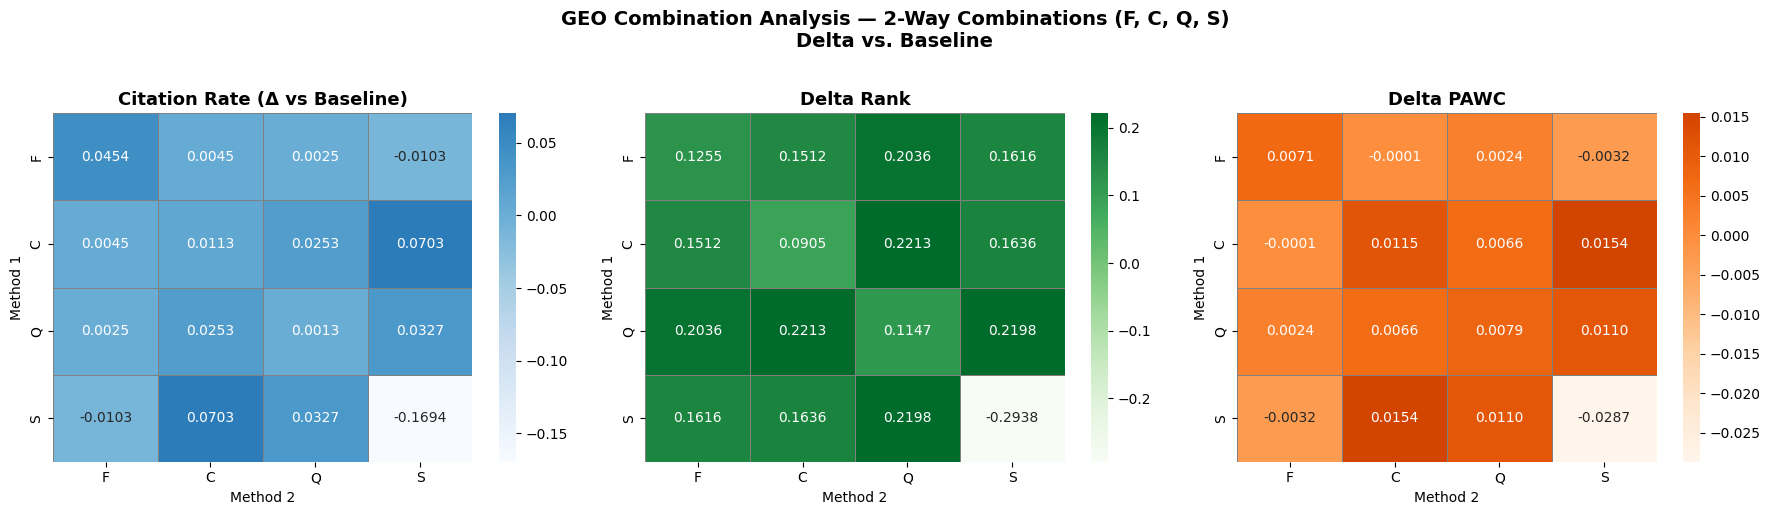

In [47]:
base_methods = ["F", "C", "Q", "S"]
combo_map = {
    ("F","C"): "FC", ("C","F"): "FC", ("F","Q"): "FQ", ("Q","F"): "FQ",
    ("F","S"): "FS", ("S","F"): "FS", ("C","Q"): "CQ", ("Q","C"): "CQ",
    ("C","S"): "CS", ("S","C"): "CS", ("Q","S"): "QS", ("S","Q"): "QS",
}

def build_heatmap_matrix(df_combined, metric_col):
    label_to_val = dict(zip(df_combined["label"], df_combined[metric_col]))
    matrix = np.zeros((4, 4))
    for i, m1 in enumerate(base_methods):
        for j, m2 in enumerate(base_methods):
            if i == j:
                matrix[i][j] = label_to_val.get(m1, 0)
            else:
                combo = combo_map.get((m1, m2))
                matrix[i][j] = label_to_val.get(combo, 0) if combo else 0
    return matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [
    ("delta_citation_rate", "Citation Rate (Δ vs Baseline)", "Blues"),
    ("delta_rank",          "Delta Rank",                    "Greens"),
    ("mean_delta_pawc",     "Delta PAWC",                    "Oranges"),
]
for ax, (metric_col, title, cmap) in zip(axes, metrics):
    matrix = build_heatmap_matrix(df_combined, metric_col)
    sns.heatmap(matrix, ax=ax, annot=True, fmt=".4f", xticklabels=base_methods, yticklabels=base_methods,
                cmap=cmap, center=0, linewidths=0.5, linecolor="gray")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Method 2")
    ax.set_ylabel("Method 1")
plt.suptitle("GEO Combination Analysis — 2-Way Combinations (F, C, Q, S)\nDelta vs. Baseline",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

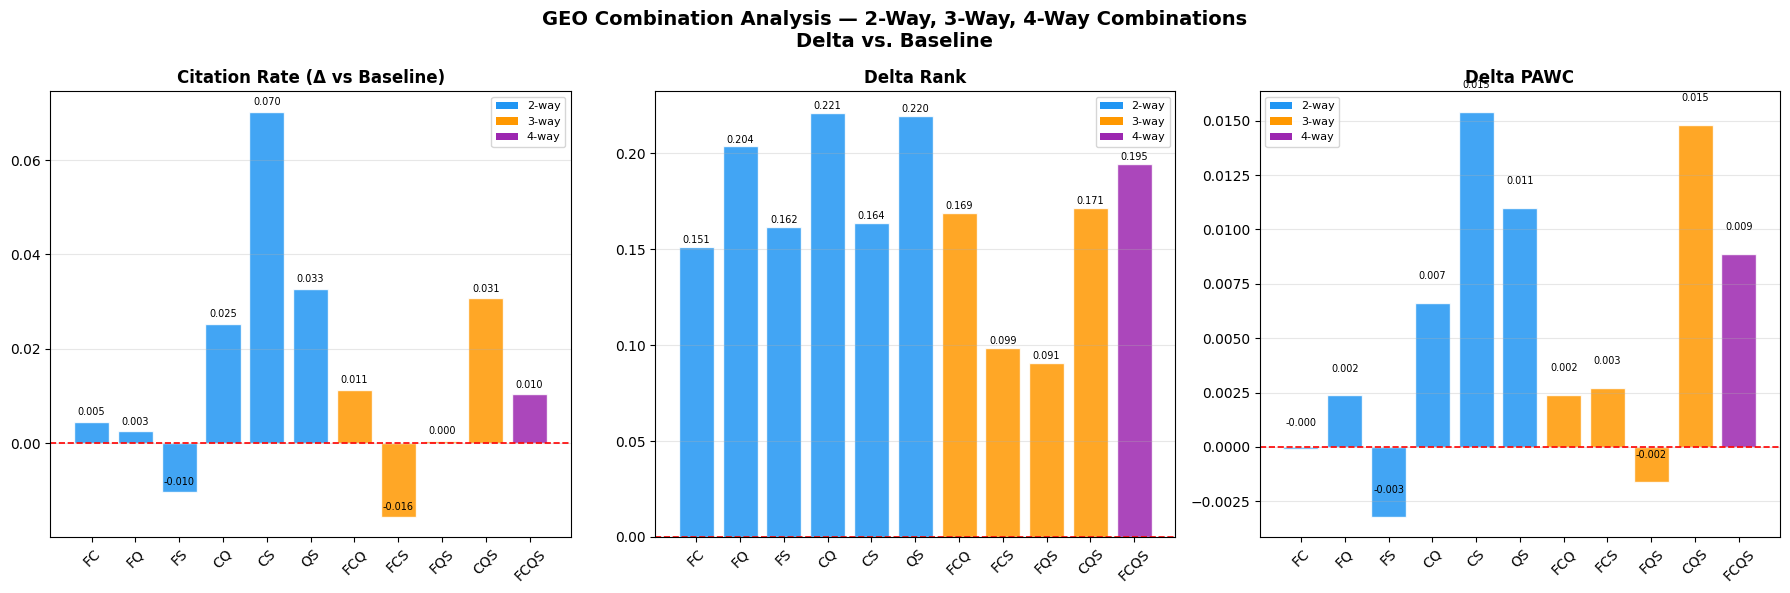

In [48]:
from matplotlib.patches import Patch

combos_2way = ["FC", "FQ", "FS", "CQ", "CS", "QS"]
combos_3way = ["FCQ", "FCS", "FQS", "CQS"]
combos_4way = ["FCQS"]
all_combo_labels = combos_2way + combos_3way + combos_4way

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics_bar = [
    ("delta_citation_rate", "Citation Rate (Δ vs Baseline)"),
    ("delta_rank",          "Delta Rank"),
    ("mean_delta_pawc",     "Delta PAWC"),
]
bar_colors = ["#2196F3"] * 6 + ["#FF9800"] * 4 + ["#9C27B0"] * 1

for ax, (col, title) in zip(axes, metrics_bar):
    df_plot = df_combined[df_combined["label"].isin(all_combo_labels)].copy()
    df_plot = df_plot.set_index("label").reindex(all_combo_labels).reset_index()
    bars = ax.bar(df_plot["label"], df_plot[col], color=bar_colors, alpha=0.85, edgecolor="white")
    ax.axhline(y=0, color="red", linestyle="--", linewidth=1.2)
    for bar, val in zip(bars, df_plot[col]):
        if pd.notna(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=7)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(handles=[
        Patch(facecolor="#2196F3", label="2-way"),
        Patch(facecolor="#FF9800", label="3-way"),
        Patch(facecolor="#9C27B0", label="4-way"),
    ], fontsize=8)

plt.suptitle("GEO Combination Analysis — 2-Way, 3-Way, 4-Way Combinations\nDelta vs. Baseline",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()